### Import and Load Datsets

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


In [2]:
# Load datasets
# Training set (2021=2024)
train_df = pd.read_csv(r"training sets\train_daily_revenue.csv", parse_dates=['close_date'])

# Test set (2025)
test_df = pd.read_csv(r"training sets\test_future_dates.csv", parse_dates=['close_date'])


In [3]:
# Define columns that need encoding 
categorical_cols = ['product', 'series', 'office_location', 'type']

# Define the target variable
TARGET = 'total_revenue'

# Fit encoder on training data 
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_df[categorical_cols])

# Transform training data 
train_encoded_array = encoder.transform(train_df[categorical_cols])
train_encoded_cols = encoder.get_feature_names_out(categorical_cols)
train_encoded_df = pd.DataFrame(
    train_encoded_array, 
    columns=train_encoded_cols,
    index=train_df.index
)

# Drop original categorical columns and concatenate encoded columns
train_df_encoded = pd.concat(
    [train_df.drop(columns=categorical_cols), train_encoded_df], 
    axis=1
)

# Transform test data using the same encoder
test_encoded_array = encoder.transform(test_df[categorical_cols])
test_encoded_df = pd.DataFrame(
    test_encoded_array, 
    columns=train_encoded_cols,  # Use the same column names as training
    index=test_df.index
)

# Drop original categorical columns and concatenate encoded columns
test_df_encoded = pd.concat(
    [test_df.drop(columns=categorical_cols), test_encoded_df], 
    axis=1
)

# Print shapes and sample encoded columns
print(f"train_df_encoded: {train_df_encoded.shape[0]} rows × {train_df_encoded.shape[1]} cols")
print(f"test_df_encoded:  {test_df_encoded.shape[0]} rows × {test_df_encoded.shape[1]} cols")
print(f"\nEncoded columns added: {len(train_encoded_cols)}")
print(f"Sample encoded columns: {list(train_encoded_cols[:6])}")

train_df_encoded: 4659 rows × 46 cols
test_df_encoded:  18250 rows × 46 cols

Encoded columns added: 36
Sample encoded columns: ['product_Analytics Basic', 'product_Analytics Pro', 'product_Analytics Suite', 'product_CoreCRM Enterprise', 'product_CoreCRM Pro', 'product_CoreCRM Starter']


### Exploratory Data Analysis

Descriptive Statistics for Training Data:
       total_revenue  total_deals  avg_deal_size  avg_days_to_close  \
count        4659.00      4659.00        4659.00            4659.00   
mean         4398.09         1.01        4345.69              52.26   
std          5625.82         0.11        5528.43              34.00   
min           748.53         1.00         748.53             -14.00   
25%          1219.20         1.00        1213.55              29.00   
50%          2603.09         1.00        2572.02              42.00   
75%          4459.76         1.00        4437.02              71.00   
max         41524.52         3.00       27554.57             212.00   

       quarter_end_flag  
count           4659.00  
mean               0.42  
std                0.49  
min                0.00  
25%                0.00  
50%                0.00  
75%                1.00  
max                1.00  

── Revenue Distribution ──


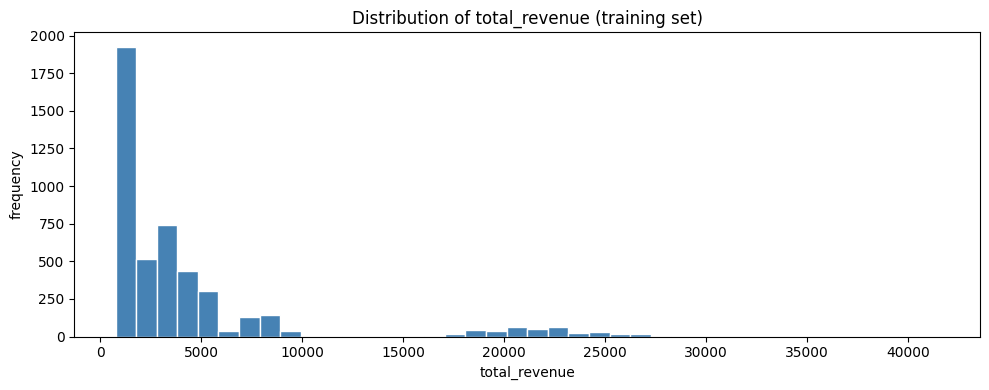


── Revenue Over Time ──


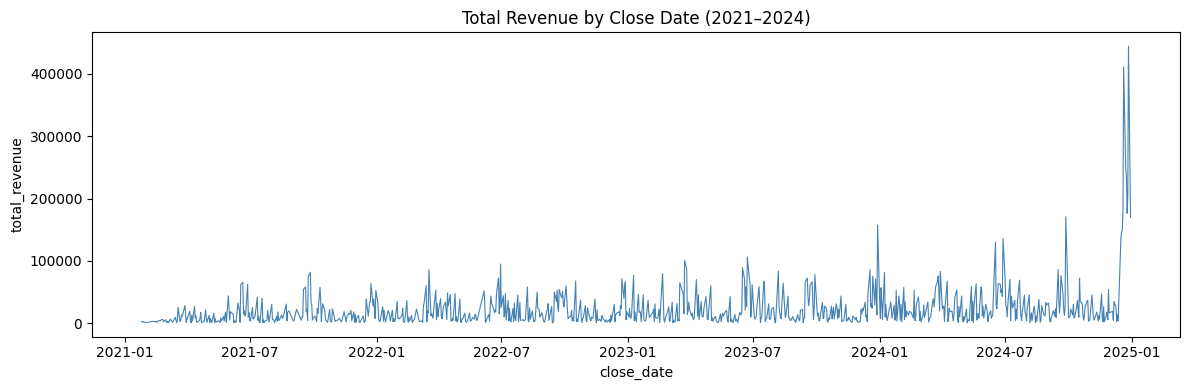


── Correlation Heatmap ──


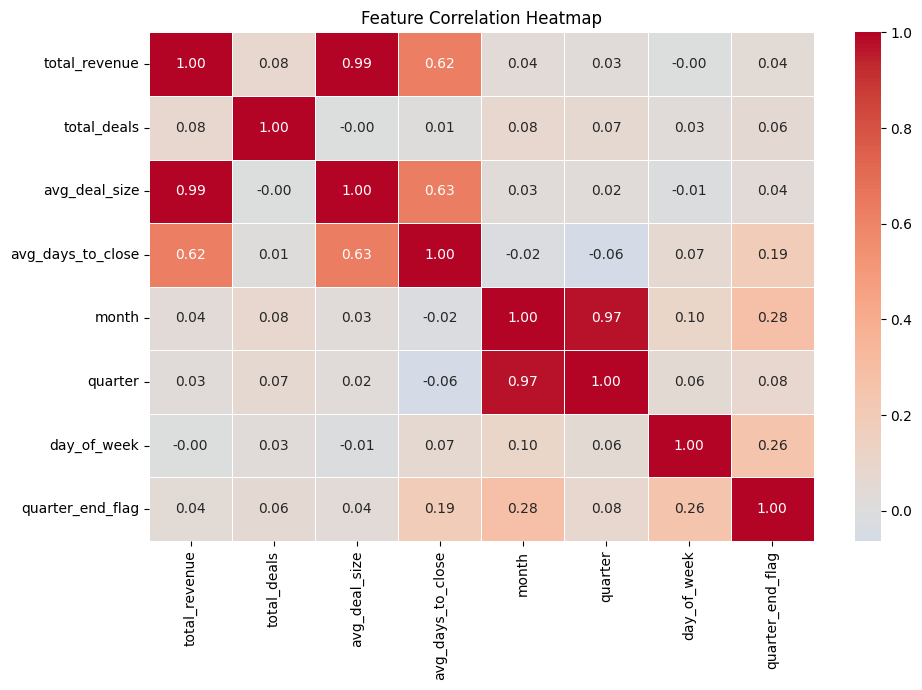


── Revenue by Product Series ──
series
Analytics       7496328.79
CoreCRM         7188373.40
MarketingHub    2189843.00
SupportDesk     1865189.73
Add-Ons         1750986.89
Name: total_revenue, dtype: float64

── Revenue by Office Location ──
office_location
Singapore         4037257.45
Japan             1890900.04
Brazil            1601504.42
Australia         1391434.37
Spain             1355055.46
UAE               1274285.51
Canada            1268182.30
Netherlands       1249309.01
Germany           1238304.02
France            1074453.46
United Kingdom    1029611.75
Mexico             949923.92
India              934947.61
Sweden             852209.03
United States      343343.46
Name: total_revenue, dtype: float64

── Revenue by Deal Type ──
type
New Business    9141459.32
Renewal         6345463.85
Upsell          2834784.04
Cross-sell      2169014.60
Name: total_revenue, dtype: float64


In [4]:
# Descriptive Stats
print("Descriptive Statistics for Training Data:")
print(train_df[['total_revenue', 'total_deals', 'avg_deal_size', 'avg_days_to_close', 'quarter_end_flag']]
      .describe().round(2))

# Revenue Distribution Plot
print("\n── Revenue Distribution ──")
plt.figure(figsize=(10, 4))
plt.hist(train_df['total_revenue'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of total_revenue (training set)')
plt.xlabel('total_revenue')
plt.ylabel('frequency')
plt.tight_layout()
plt.show()

# Revenue Over Time Plot
print("\n── Revenue Over Time ──")
daily_revenue = train_df.groupby('close_date')['total_revenue'].sum()
plt.figure(figsize=(12, 4))
plt.plot(daily_revenue.index, daily_revenue.values, color='steelblue', linewidth=0.8)
plt.title('Total Revenue by Close Date (2021–2024)')
plt.xlabel('close_date')
plt.ylabel('total_revenue')
plt.tight_layout()
plt.show()

# Correlation Heatmap
numeric_cols = ['total_revenue', 'total_deals', 'avg_deal_size',
                'avg_days_to_close', 'month', 'quarter',
                'day_of_week', 'quarter_end_flag']

print("\n── Correlation Heatmap ──")
plt.figure(figsize=(10, 7))
sns.heatmap(
    train_df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Revenue by Segment Plot
print("\n── Revenue by Product Series ──")
print(train_df.groupby('series')['total_revenue'].sum().sort_values(ascending=False).round(2))

print("\n── Revenue by Office Location ──")
print(train_df.groupby('office_location')['total_revenue'].sum().sort_values(ascending=False).round(2))

print("\n── Revenue by Deal Type ──")
print(train_df.groupby('type')['total_revenue'].sum().sort_values(ascending=False).round(2))

In [5]:
# Clean up after EDA

# Action 1: Remove outliers from training data
revenue_cap = train_df_encoded['total_revenue'].quantile(0.99)
print(f"99th percentile revenue cap: ${revenue_cap:,.2f}")

rows_above_cap = (train_df_encoded['total_revenue'] > revenue_cap).sum()
print(f"Rows above cap (will be capped): {rows_above_cap}")

train_df_encoded['total_revenue'] = train_df_encoded['total_revenue'].clip(upper=revenue_cap)
print(f"Revenue capped at ${revenue_cap:,.2f} — max is now ${train_df_encoded['total_revenue'].max():,.2f}")

# Action 2: Drop avg_deal_size 
# Correlation with total_revenue was 0.99 — nearly identical since most rows
# have only 1 deal, making avg_deal_size = total_revenue for most records.
train_df_encoded = train_df_encoded.drop(columns=['avg_deal_size'])
test_df_encoded  = test_df_encoded.drop(columns=['avg_deal_size'])

# Action 3: Drop quarter
# Correlation with month was 0.97 — quarter is almost entirely redundant 
train_df_encoded = train_df_encoded.drop(columns=['quarter'])
test_df_encoded  = test_df_encoded.drop(columns=['quarter'])

FEATURES = [col for col in train_df_encoded.columns
            if col not in ['close_date', 'total_revenue', 'total_deals',
                           'avg_deal_size']]

print(f"\nFinal feature count: {len(FEATURES)}")
print(f"Features: {FEATURES}")
print(f"\nFinal train shape: {train_df_encoded.shape}")
print(f"Final test shape:  {test_df_encoded.shape}")


99th percentile revenue cap: $25,157.74
Rows above cap (will be capped): 47
Revenue capped at $25,157.74 — max is now $25,157.74

Final feature count: 41
Features: ['month', 'day_of_week', 'year', 'avg_days_to_close', 'quarter_end_flag', 'product_Analytics Basic', 'product_Analytics Pro', 'product_Analytics Suite', 'product_CoreCRM Enterprise', 'product_CoreCRM Pro', 'product_CoreCRM Starter', 'product_DataSync Connector', 'product_Integration Pack', 'product_MarketingHub Lite', 'product_MarketingHub Pro', 'product_SupportDesk Basic', 'product_SupportDesk Pro', 'series_Add-Ons', 'series_Analytics', 'series_CoreCRM', 'series_MarketingHub', 'series_SupportDesk', 'office_location_Australia', 'office_location_Brazil', 'office_location_Canada', 'office_location_France', 'office_location_Germany', 'office_location_India', 'office_location_Japan', 'office_location_Mexico', 'office_location_Netherlands', 'office_location_Singapore', 'office_location_Spain', 'office_location_Sweden', 'office_lo

### Time-Based Training / Validation Split 
We split the training data into two periods: a training split the model
learns from, and a validation split it has never seen. This is to measure how
accurately it forecasts before we trust it on the 2025 test set.

In [6]:
#   Train split: 2021–2023 (model learns patterns from these years)
#   Val split: 2024 (model predicts 2024 as if it were the future)

SPLIT_DATE = '2023-12-31'

# Split 
train_split = train_df_encoded[train_df_encoded['close_date'] <= SPLIT_DATE]
val_split   = train_df_encoded[train_df_encoded['close_date'] > SPLIT_DATE]

x_train = train_split[FEATURES]
y_train = train_split[TARGET]

x_val = val_split[FEATURES]
y_val = val_split[TARGET]

print(f"Split date: {SPLIT_DATE}")
print(f"\nTrain split: {train_split.shape[0]} rows")
print(f"  Date range: {train_split['close_date'].min().date()} → {train_split['close_date'].max().date()}")
print(f"  X_train shape: {x_train.shape}")
print(f"  y_train shape: {y_train.shape}")

print(f"\nValidation split: {val_split.shape[0]} rows")
print(f"  Date range: {val_split['close_date'].min().date()} → {val_split['close_date'].max().date()}")
print(f"  X_val shape: {x_val.shape}")
print(f"  y_val shape: {y_val.shape}")

print(f"\nTrain % of data: {train_split.shape[0] / train_df_encoded.shape[0] * 100:.1f}%")
print(f"Val   % of data: {val_split.shape[0]   / train_df_encoded.shape[0] * 100:.1f}%")


Split date: 2023-12-31

Train split: 2965 rows
  Date range: 2021-01-25 → 2023-12-29
  X_train shape: (2965, 41)
  y_train shape: (2965,)

Validation split: 1694 rows
  Date range: 2024-01-01 → 2024-12-30
  X_val shape: (1694, 41)
  y_val shape: (1694,)

Train % of data: 63.6%
Val   % of data: 36.4%


### XGBoost Hyperparameter Tuning

In [7]:
# Hyperparameter values 
xgb_n_estimators = [75, 120, 150]
xgb_max_depths   = [7, 8, 10, 12]

# Tuning Loop
xgb_best_rmse   = float('inf') 
xgb_best_params = {}
xgb_results     = []

print("XGBoost Hyperparameter Tuning")
print(f"{'n_estimators':>14} {'max_depth':>10} {'RMSE':>12}")
print("-" * 40)


for n in xgb_n_estimators:
    for d in xgb_max_depths:

        model = XGBRegressor(
            n_estimators=n,
            max_depth=d,
            random_state=42,      
            verbosity=0           
        )

        model.fit(x_train, y_train)
        preds = model.predict(x_val)
        rmse = mean_squared_error(y_val, preds) ** 0.5

        xgb_results.append({'n_estimators': n, 'max_depth': d, 'rmse': rmse})

        print(f"{n:>14} {d:>10} ${rmse:>11,.2f}")

        if rmse < xgb_best_rmse:
            xgb_best_rmse   = rmse
            xgb_best_params = {'n_estimators': n, 'max_depth': d}

# Refit best model on full training data (2021–2024)
xgb_best_model = XGBRegressor(
    n_estimators=xgb_best_params['n_estimators'],
    max_depth=xgb_best_params['max_depth'],
    random_state=42,
    verbosity=0
)
xgb_best_model.fit(train_df_encoded[FEATURES], train_df_encoded[TARGET])

print(f"\nBest XGBoost params: {xgb_best_params}")
print(f"Best XGBoost RMSE:   ${xgb_best_rmse:,.2f}")

XGBoost Hyperparameter Tuning
  n_estimators  max_depth         RMSE
----------------------------------------
            75          7 $     936.49
            75          8 $     928.06
            75         10 $     953.38
            75         12 $     945.00
           120          7 $     941.58
           120          8 $     929.89
           120         10 $     953.88
           120         12 $     945.09
           150          7 $     942.09
           150          8 $     930.83
           150         10 $     953.97
           150         12 $     945.09

Best XGBoost params: {'n_estimators': 75, 'max_depth': 8}
Best XGBoost RMSE:   $928.06


### Random Forest Hyperparameter Tuning

In [8]:
# Same process for Random Forest
rf_n_estimators = [75, 120, 150]
rf_max_depths   = [7, 8, 10, 12]

rf_best_rmse   = float('inf')
rf_best_params = {}
rf_results     = []

print("Random Forest Hyperparameter Tuning")
print(f"{'n_estimators':>14} {'max_depth':>10} {'RMSE':>12}")
print("-" * 40)

for n in rf_n_estimators:
    for d in rf_max_depths:

        model = RandomForestRegressor(
            n_estimators=n,
            max_depth=d,
            random_state=42,      
            n_jobs=-1             
        )

        model.fit(x_train, y_train)
        preds = model.predict(x_val)
        rmse  = mean_squared_error(y_val, preds) ** 0.5

        rf_results.append({'n_estimators': n, 'max_depth': d, 'rmse': rmse})

        print(f"{n:>14} {d:>10} ${rmse:>11,.2f}")

        if rmse < rf_best_rmse:
            rf_best_rmse   = rmse
            rf_best_params = {'n_estimators': n, 'max_depth': d}

rf_best_model = RandomForestRegressor(
    n_estimators=rf_best_params['n_estimators'],
    max_depth=rf_best_params['max_depth'],
    random_state=42,
    n_jobs=-1
)
rf_best_model.fit(train_df_encoded[FEATURES], train_df_encoded[TARGET])

print(f"\nBest Random Forest params: {rf_best_params}")
print(f"Best Random Forest RMSE:   ${rf_best_rmse:,.2f}")

Random Forest Hyperparameter Tuning
  n_estimators  max_depth         RMSE
----------------------------------------
            75          7 $     975.20
            75          8 $     916.75
            75         10 $     872.21
            75         12 $     866.35
           120          7 $     980.96
           120          8 $     920.37
           120         10 $     871.96
           120         12 $     865.76
           150          7 $     978.39
           150          8 $     922.35
           150         10 $     874.25
           150         12 $     870.67

Best Random Forest params: {'n_estimators': 120, 'max_depth': 12}
Best Random Forest RMSE:   $865.76


In [9]:
# Side-by-side comparison of best models
print(f"\n{'─' * 40}")
print(f"{'Model':<20} {'Best RMSE':>12}")
print(f"{'─' * 40}")
print(f"{'XGBoost':<20} ${xgb_best_rmse:>11,.2f}")
print(f"{'Random Forest':<20} ${rf_best_rmse:>11,.2f}")
print(f"{'─' * 40}")


────────────────────────────────────────
Model                   Best RMSE
────────────────────────────────────────
XGBoost              $     928.06
Random Forest        $     865.76
────────────────────────────────────────


Random Forest is are best model. Random Forest's predictions are on average ~$1,000 closer to actual revenue per date × segment row.

###  Model Evaluation

── Validation Set Performance (2024) ──
  RMSE: $350.20 
  MAE:  $207.99 
  R²:   0.9968 

  R² interpretation: Strong fit — model explains most revenue variance

── Top 15 Most Important Features ──
                   feature  importance
   product_Analytics Suite    0.439341
product_CoreCRM Enterprise    0.415679
     product_Analytics Pro    0.069577
       product_CoreCRM Pro    0.026727
  product_MarketingHub Pro    0.012440
   product_SupportDesk Pro    0.008589
         avg_days_to_close    0.006925
product_DataSync Connector    0.005671
                      year    0.003309
          series_Analytics    0.001709
                     month    0.001637
   product_Analytics Basic    0.001546
               day_of_week    0.001112
 office_location_Singapore    0.000747
              type_Renewal    0.000400


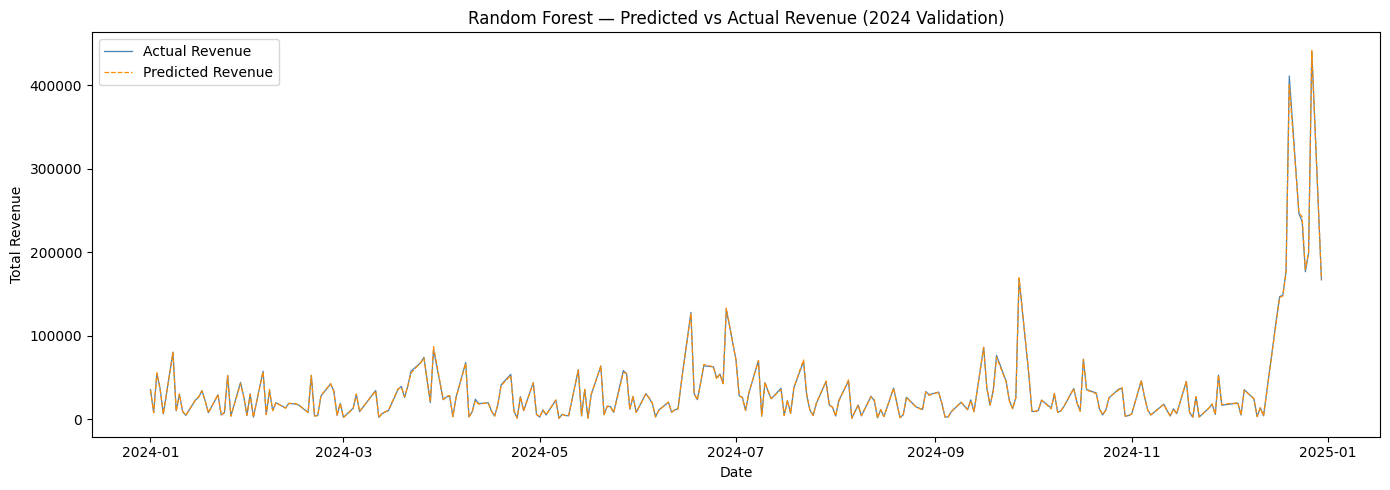

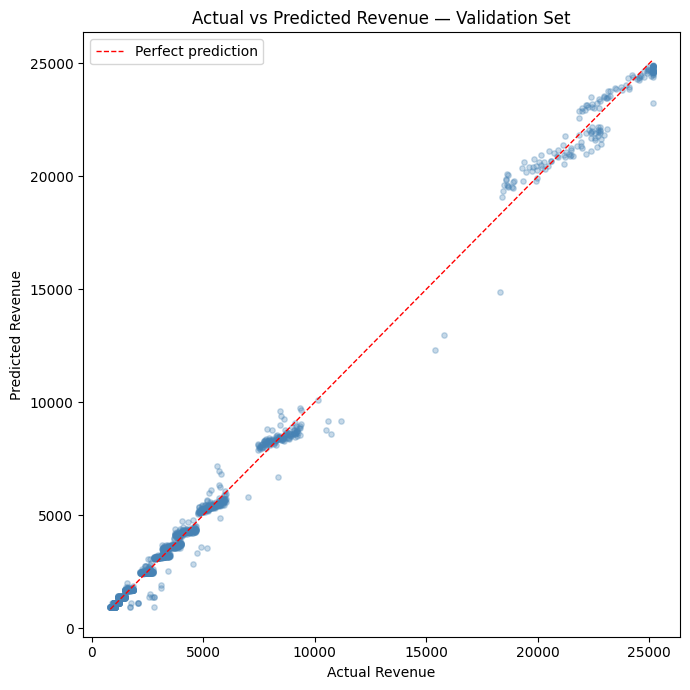

In [10]:
val_preds = rf_best_model.predict(x_val) # 2021-2023

# Clipping negative predictions to 0 
val_preds = val_preds.clip(min=0)

# Performance metrics: 2024 (y_val) compared to model's predictions of 2024 (val_preds)
rmse = mean_squared_error(y_val, val_preds) ** 0.5 
mae = mean_absolute_error(y_val, val_preds) 
r2 = r2_score(y_val, val_preds)

print("── Validation Set Performance (2024) ──")
print(f"  RMSE: ${rmse:,.2f} ")
print(f"  MAE:  ${mae:,.2f} ")
print(f"  R²:   {r2:.4f} ")

if r2 >= 0.80:
    print("\n  R² interpretation: Strong fit — model explains most revenue variance")
elif r2 >= 0.60:
    print("\n  R² interpretation: Moderate fit — model captures broad patterns")
elif r2 >= 0.40:
    print("\n  R² interpretation: Weak fit — model misses meaningful patterns")
else:
    print("\n  R² interpretation: Poor fit — consider revisiting features or data")

# Feature importance - which features did the model rely on most while making predictions? 
importance_df = pd.DataFrame({
    'feature':   FEATURES,
    'importance': rf_best_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print("\n── Top 15 Most Important Features ──")
print(importance_df.to_string(index=False))

# Predicted vs. Actual
val_plot_df = val_split[['close_date']].copy()
val_plot_df['actual']    = y_val.values
val_plot_df['predicted'] = val_preds

daily_val = val_plot_df.groupby('close_date')[['actual', 'predicted']].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_val.index, daily_val['actual'],
         label='Actual Revenue', color='steelblue', linewidth=0.9)
plt.plot(daily_val.index, daily_val['predicted'],
         label='Predicted Revenue', color='darkorange',
         linewidth=0.9, linestyle='--')
plt.title('Random Forest — Predicted vs Actual Revenue (2024 Validation)')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(y_val, val_preds, alpha=0.3, color='steelblue', s=15)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='red', linewidth=1, linestyle='--', label='Perfect prediction')
plt.title('Actual vs Predicted Revenue — Validation Set')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.legend()
plt.tight_layout()
plt.show()

### Generate 2025 Forecast & Build Final Combined File

In [11]:
X_test = test_df_encoded[FEATURES]

test_predictions = rf_best_model.predict(X_test)

test_predictions = test_predictions.clip(min=0)

test_df_encoded['total_revenue'] = test_predictions

print(f"2025 predictions generated: {len(test_predictions):,} rows")
print(f"Predicted revenue range: ${test_predictions.min():,.2f} → ${test_predictions.max():,.2f}")
print(f"Total predicted 2025 revenue: ${test_predictions.sum():,.2f}")

historical_df = train_df.copy()
historical_df['is_forecast'] = 0

forecast_df = test_df.copy()
forecast_df['total_revenue'] = test_predictions
forecast_df['is_forecast']   = 1

dashboard_cols = [
    'close_date',
    'month',
    'day_of_week',
    'year',
    'quarter_end_flag',
    'product',
    'series',
    'office_location',
    'type',
    'total_revenue',
    'total_deals',
    'is_forecast'
]

forecast_df['total_deals'] = 0
historical_df = historical_df[dashboard_cols]
forecast_df   = forecast_df[dashboard_cols]

combined_df = (
    pd.concat([historical_df, forecast_df], ignore_index=True)
    .sort_values('close_date')
    .reset_index(drop=True)
)

print(f"\nCombined dataset shape: {combined_df.shape}")
print(f"Date range: {combined_df['close_date'].min()} → {combined_df['close_date'].max()}")
print(f"\nHistorical rows (is_forecast=0): {(combined_df['is_forecast']==0).sum():,}")
print(f"Forecast rows  (is_forecast=1): {(combined_df['is_forecast']==1).sum():,}")
print(f"\nHistorical total revenue: ${combined_df[combined_df['is_forecast']==0]['total_revenue'].sum():,.2f}")
print(f"Forecast total revenue:   ${combined_df[combined_df['is_forecast']==1]['total_revenue'].sum():,.2f}")
print(f"\nNull check:\n{combined_df.isnull().sum()}")
print(f"\nPreview of transition from historical to forecast:")
transition = combined_df[combined_df['close_date'] >= '2024-12-28'].head(8)
display(transition[['close_date','product','office_location','type',
                     'total_revenue','is_forecast']])

combined_df.to_csv('final_combined_forecast.csv', index=False)
print(f"\nSaved final_combined_forecast.csv")                     

2025 predictions generated: 18,250 rows
Predicted revenue range: $940.11 → $21,820.58
Total predicted 2025 revenue: $57,200,405.14

Combined dataset shape: (22909, 12)
Date range: 2021-01-25 00:00:00 → 2025-12-31 00:00:00

Historical rows (is_forecast=0): 4,659
Forecast rows  (is_forecast=1): 18,250

Historical total revenue: $20,490,721.81
Forecast total revenue:   $57,200,405.14

Null check:
close_date          0
month               0
day_of_week         0
year                0
quarter_end_flag    0
product             0
series              0
office_location     0
type                0
total_revenue       0
total_deals         0
is_forecast         0
dtype: int64

Preview of transition from historical to forecast:


,close_date,product,office_location,type,total_revenue,is_forecast
4628,2024-12-30,CoreCRM Pro,UAE,Renewal,4823.88,0
4629,2024-12-30,CoreCRM Pro,Netherlands,Renewal,5946.27,0
4630,2024-12-30,CoreCRM Pro,Brazil,New Business,5267.91,0
4631,2024-12-30,CoreCRM Enterprise,United Kingdom,New Business,18872.41,0
4632,2024-12-30,CoreCRM Enterprise,France,Upsell,18650.93,0
4633,2024-12-30,Analytics Suite,Brazil,Renewal,27128.82,0
4634,2024-12-30,Analytics Basic,UAE,New Business,2405.04,0
4635,2024-12-30,Analytics Pro,Singapore,Renewal,9129.39,0



Saved final_combined_forecast.csv
